In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the Spotter assessment data
train = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\train-test.csv')
val = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\validation.csv')
december = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\december-chart-inputs.csv')
template = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\validation-predictions-template.csv')

print("=" * 60)
print("TRAIN/TEST")
print("=" * 60)
print(f"Shape: {train.shape}")
print(f"\nColumns:\n{train.columns.tolist()}")
print(f"\nDtypes:\n{train.dtypes}")
print(f"\nMissing:\n{train.isnull().sum()}")
print(f"\nFirst 3 rows:\n{train.head(3)}")

print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)
print(f"Shape: {val.shape}")
print(f"Columns: {val.columns.tolist()}")
print(val.head(3))

print("\n" + "=" * 60)
print("DECEMBER CHART")
print("=" * 60)
print(f"Shape: {december.shape}")
print(f"Columns: {december.columns.tolist()}")
print(december.head(3))

print("\n" + "=" * 60)
print("PREDICTIONS TEMPLATE")
print("=" * 60)
print(f"Shape: {template.shape}")
print(template.head(3))

TRAIN/TEST
Shape: (48000, 14)

Columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Dtypes:
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

Missing:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

First 3 rows:
     load_id        pickup      delivery  pickup_lat  pickup_lon  \
0  TR-000001      Richmond     

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

# Load data
train = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\train-test.csv')
val = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\validation.csv')
december = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\december-chart-inputs.csv')
template = pd.read_csv(r'C:\Users\Administrator\Documents\ai\spotter\validation-predictions-template.csv')

# Constants
TARGET = 'posted_rate'
ID_COL = 'load_id'
DATE_COL = 'date'

print("Data loaded successfully!")
print(f"Train: {train.shape}, Val: {val.shape}, December: {december.shape}")

Data loaded successfully!
Train: (48000, 14), Val: (12000, 13), December: (31, 7)


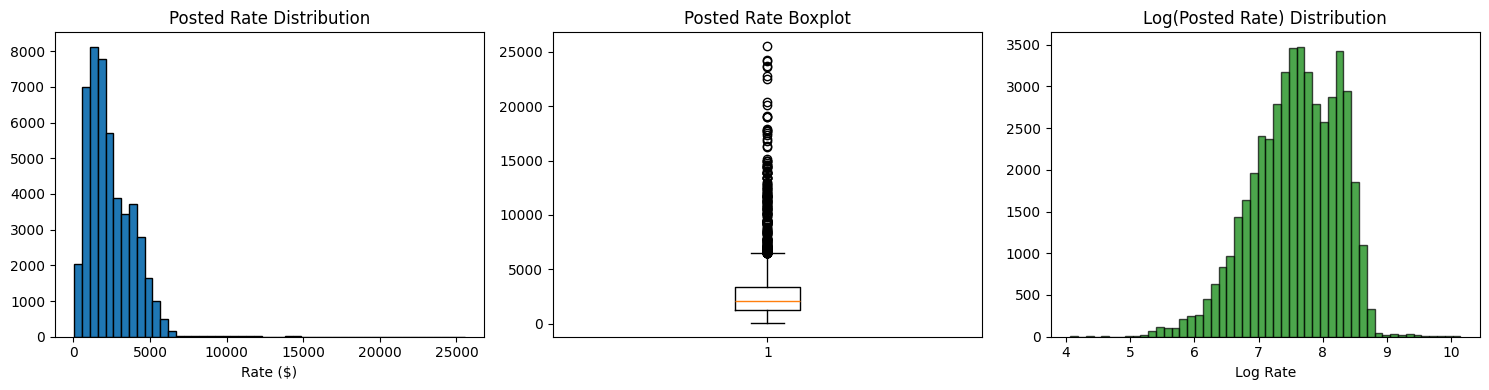

Date range: 2025-01-01 00:00:00 to 2025-10-31 00:00:00
Unique months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]

Monthly stats:
                mean    median  count
date                                 
2025-01  2255.967048  1915.200   4918
2025-02  2273.804801  1994.250   4337
2025-03  2372.268092  2022.920   5036
2025-04  2372.162308  2044.240   4819
2025-05  2421.776342  2065.510   4913
2025-06  2497.030115  2120.220   4783
2025-07  2415.162030  2059.145   4912
2025-08  2338.407661  2015.730   4759
2025-09  2406.374013  2057.130   4670
2025-10  2379.051374  2035.900   4853


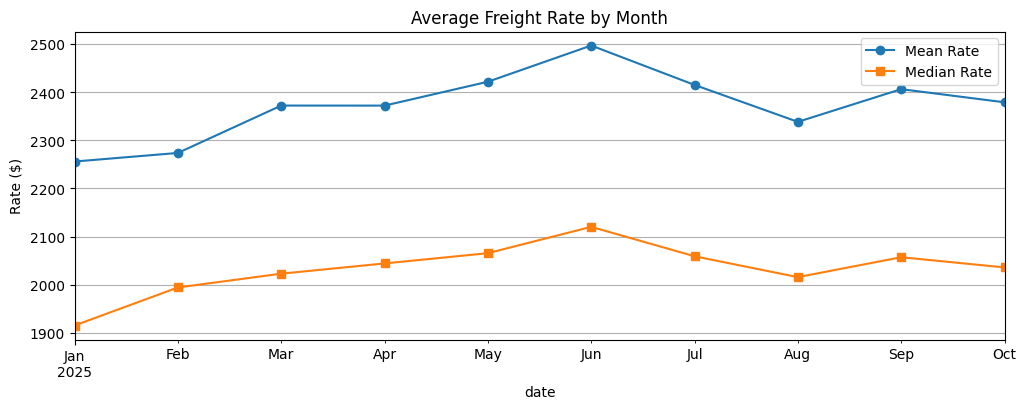


Equipment types:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


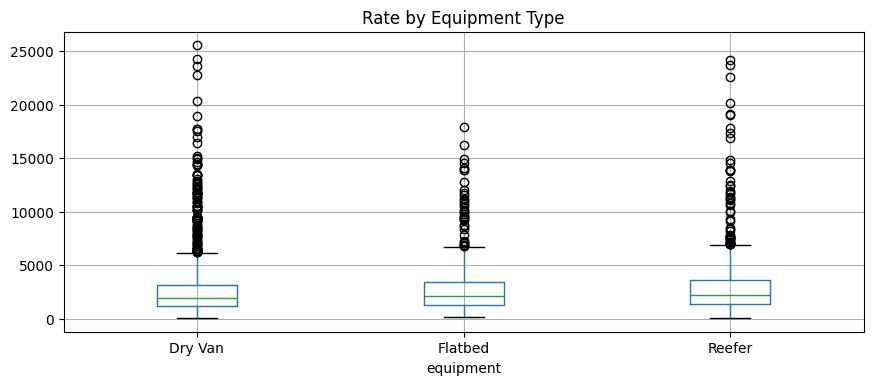

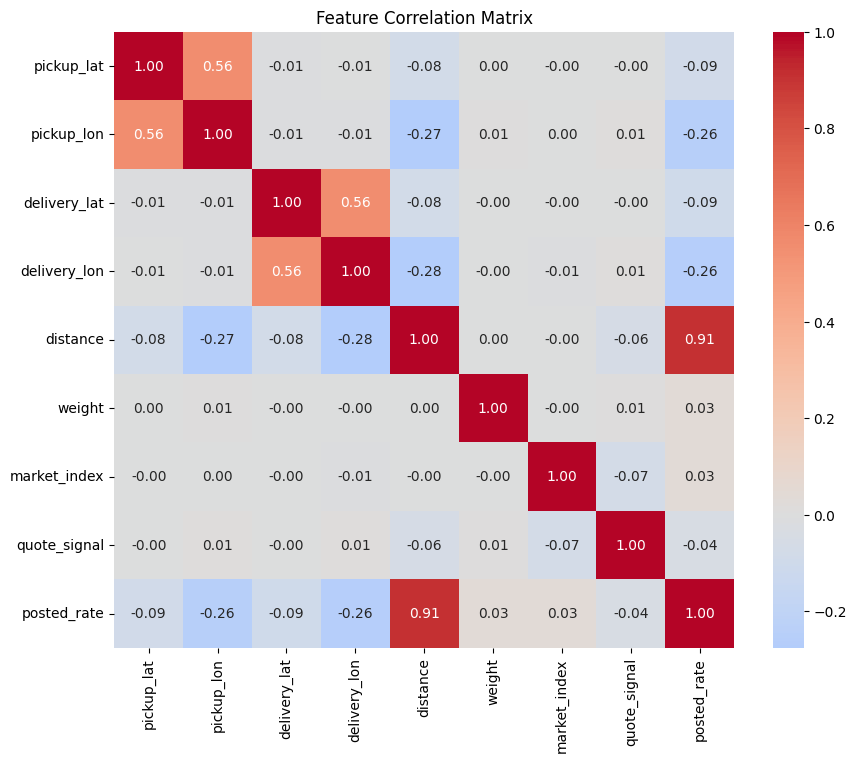


Top correlations with posted_rate:
posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64


In [14]:
# Parse dates
train[DATE_COL] = pd.to_datetime(train[DATE_COL])
val[DATE_COL] = pd.to_datetime(val[DATE_COL])
december[DATE_COL] = pd.to_datetime(december[DATE_COL])

# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(train[TARGET], bins=50, edgecolor='black')
axes[0].set_title('Posted Rate Distribution')
axes[0].set_xlabel('Rate ($)')

axes[1].boxplot(train[TARGET])
axes[1].set_title('Posted Rate Boxplot')

axes[2].hist(np.log1p(train[TARGET]), bins=50, edgecolor='black', color='green', alpha=0.7)
axes[2].set_title('Log(Posted Rate) Distribution')
axes[2].set_xlabel('Log Rate')

plt.tight_layout()
plt.show()

# Date range
print(f"Date range: {train[DATE_COL].min()} to {train[DATE_COL].max()}")
print(f"Unique months: {sorted(train[DATE_COL].dt.month.unique())}")

# Monthly rate trends
monthly = train.groupby(train[DATE_COL].dt.to_period('M'))[TARGET].agg(['mean', 'median', 'count'])
print("\nMonthly stats:")
print(monthly)

plt.figure(figsize=(12, 4))
monthly['mean'].plot(marker='o', label='Mean Rate')
monthly['median'].plot(marker='s', label='Median Rate')
plt.title('Average Freight Rate by Month')
plt.ylabel('Rate ($)')
plt.legend()
plt.grid(True)
plt.show()

# Equipment type analysis
print("\nEquipment types:")
print(train['equipment'].value_counts())

plt.figure(figsize=(10, 4))
train.boxplot(column=TARGET, by='equipment', ax=plt.gca())
plt.title('Rate by Equipment Type')
plt.suptitle('')
plt.show()

# Correlation matrix
numeric_cols = ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 
                'distance', 'weight', 'market_index', 'quote_signal', TARGET]
corr = train[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

print("\nTop correlations with posted_rate:")
print(corr[TARGET].sort_values(ascending=False))

In [19]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ============================================================
# CELL 3: FEATURE ENGINEERING (Clean & Robust)
# ============================================================

def create_features(df, is_train=True, coord_ref=None):
    df = df.copy()
    
    # --- 1. Parse Date ---
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['month'] = df['date'].dt.month
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_december'] = (df['month'] == 12).astype(int)
    df['is_peak_season'] = df['month'].isin([10, 11, 12]).astype(int)
    df['is_january'] = (df['month'] == 1).astype(int)
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    
    # --- 2. Merge coordinates for December (if missing lat/lon) ---
    if 'pickup_lat' not in df.columns and coord_ref is not None:
        city_coords = coord_ref.groupby('pickup')[['pickup_lat', 'pickup_lon']].first()
        city_coords_del = coord_ref.groupby('delivery')[['delivery_lat', 'delivery_lon']].first()
        df = df.merge(city_coords, left_on='pickup', right_index=True, how='left')
        df = df.merge(city_coords_del, left_on='delivery', right_index=True, how='left')
    
    # --- 3. Geographic Features ---
    if all(c in df.columns for c in ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon']):
        R = 3959
        lat1, lon1 = np.radians(df['pickup_lat']), np.radians(df['pickup_lon'])
        lat2, lon2 = np.radians(df['delivery_lat']), np.radians(df['delivery_lon'])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        df['haversine_dist'] = 2 * R * np.arcsin(np.sqrt(a))
        df['dist_diff'] = df['haversine_dist'] - df['distance']
        df['is_northbound'] = (df['delivery_lat'] > df['pickup_lat']).astype(int)
        df['is_eastbound'] = (df['delivery_lon'] > df['pickup_lon']).astype(int)
        df['lat_diff'] = df['delivery_lat'] - df['pickup_lat']
        df['lon_diff'] = df['delivery_lon'] - df['pickup_lon']
    
    # --- 4. Freight Features (NO pd.cut — avoids categorical dtype issues) ---
    df['weight_per_mile'] = df['weight'] / (df['distance'] + 1e-6)
    df['weight_dist'] = df['weight'] * df['distance']
    df['dist_sq'] = df['distance'] ** 2
    df['weight_sq'] = df['weight'] ** 2
    
    # Manual distance bins as integers (not categorical)
    df['dist_bin'] = (df['distance'] > 200).astype(int) + \
                     (df['distance'] > 500).astype(int) + \
                     (df['distance'] > 1000).astype(int) + \
                     (df['distance'] > 2000).astype(int)
    
    # --- 5. Equipment Dummies ---
    df = pd.get_dummies(df, columns=['equipment'], prefix='eq', drop_first=False)
    
    # --- 6. Lane & City Encoding ---
    df['lane'] = df['pickup'].astype(str) + '_' + df['delivery'].astype(str)
    
    # Label encode lane (not frequency — avoids unseen category issues in val/dec)
    le_lane = LabelEncoder()
    le_pickup = LabelEncoder()
    le_delivery = LabelEncoder()
    
    if is_train:
        df['lane_enc'] = le_lane.fit_transform(df['lane'])
        df['pickup_enc'] = le_pickup.fit_transform(df['pickup'])
        df['delivery_enc'] = le_delivery.fit_transform(df['delivery'])
        # Store encoders for later
        create_features.le_lane = le_lane
        create_features.le_pickup = le_pickup
        create_features.le_delivery = le_delivery
    else:
        # For val/dec: transform known, mark unknown as -1
        df['lane_enc'] = df['lane'].map(
            dict(zip(create_features.le_lane.classes_, 
                     create_features.le_lane.transform(create_features.le_lane.classes_)))
        ).fillna(-1).astype(int)
        df['pickup_enc'] = df['pickup'].map(
            dict(zip(create_features.le_pickup.classes_, 
                     create_features.le_pickup.transform(create_features.le_pickup.classes_)))
        ).fillna(-1).astype(int)
        df['delivery_enc'] = df['delivery'].map(
            dict(zip(create_features.le_delivery.classes_, 
                     create_features.le_delivery.transform(create_features.le_delivery.classes_)))
        ).fillna(-1).astype(int)
    
    # --- 7. Handle Missing Values ---
    df['weight'] = df['weight'].fillna(df['weight'].median())
    if 'market_index' in df.columns:
        df['market_index'] = df['market_index'].fillna(df['market_index'].median())
    
    # --- 8. Drop non-numeric columns ---
    drop_cols = ['load_id', 'date', 'pickup', 'delivery', 'lane']
    if 'predicted_rate' in df.columns:
        drop_cols.append('predicted_rate')
    
    df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    # Ensure all numeric (convert any remaining object columns)
    for col in df_model.columns:
        if df_model[col].dtype == 'object':
            df_model[col] = df_model[col].astype('category').cat.codes
    
    # Fill any remaining NaNs with -999
    df_model = df_model.fillna(-999)
    
    return df, df_model


# ============================================================
# APPLY
# ============================================================

print("Creating features for training data...")
train_full, train_fe = create_features(train, is_train=True)

print("Creating features for validation data...")
val_full, val_fe = create_features(val, is_train=False, coord_ref=train)

print("Creating features for December chart...")
dec_full, dec_fe = create_features(december, is_train=False, coord_ref=train)

print(f"\nTrain shape:      {train_fe.shape}")
print(f"Val shape:        {val_fe.shape}")
print(f"December shape:   {dec_fe.shape}")
print(f"\nColumns: {train_fe.columns.tolist()}")

Creating features for training data...
Creating features for validation data...
Creating features for December chart...

Train shape:      (48000, 34)
Val shape:        (12000, 33)
December shape:   (31, 29)

Columns: ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'month', 'dayofweek', 'quarter', 'is_weekend', 'is_december', 'is_peak_season', 'is_january', 'is_summer', 'haversine_dist', 'dist_diff', 'is_northbound', 'is_eastbound', 'lat_diff', 'lon_diff', 'weight_per_mile', 'weight_dist', 'dist_sq', 'weight_sq', 'dist_bin', 'eq_Dry Van', 'eq_Flatbed', 'eq_Reefer', 'lane_enc', 'pickup_enc', 'delivery_enc']


Features used: 29
['weight', 'pickup_enc', 'lon_diff', 'delivery_enc', 'lane_enc', 'is_weekend', 'dayofweek', 'delivery_lat', 'weight_per_mile', 'lat_diff', 'distance', 'quarter', 'pickup_lat', 'pickup_lon', 'is_peak_season', 'weight_dist', 'month', 'eq_Dry Van', 'delivery_lon', 'is_summer', 'dist_bin', 'is_eastbound', 'weight_sq', 'is_january', 'is_northbound', 'is_december', 'dist_sq', 'haversine_dist', 'dist_diff']

Time-based split:
Train: (38400, 29) | dates: 2025-01-01 00:00:00 to 2025-08-31 00:00:00
Val:   (9600, 29) | dates: 2025-08-31 00:00:00 to 2025-10-31 00:00:00

Training RandomForest...
MAE:  163.94
RMSE: 669.85
R²:   0.8071
MAPE: 7.21%

Training GradientBoosting...
MAE:  160.88
RMSE: 678.23
R²:   0.8022
MAPE: 6.87%

Training Ridge...
MAE:  178.92
RMSE: 639.27
R²:   0.8243
MAPE: 9.90%

🏆 BEST MODEL: GradientBoosting
MAE: 160.88


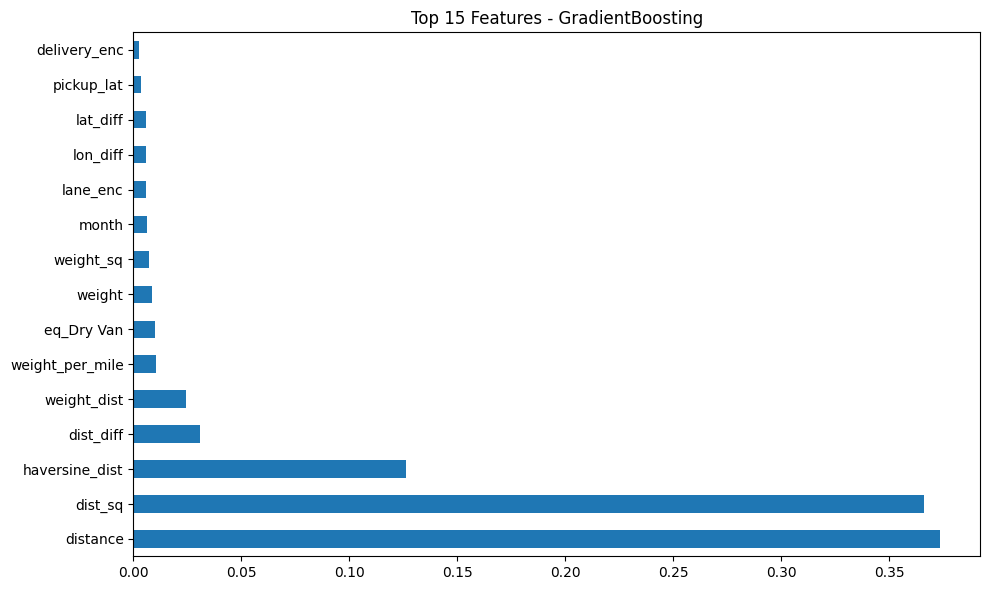


Top 5 features:
distance          0.373478
dist_sq           0.366153
haversine_dist    0.126335
dist_diff         0.030661
weight_dist       0.024314
dtype: float64


In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ============================================================
# CONFIGURE
# ============================================================
TARGET = 'posted_rate'
ID_COL = 'load_id'

# Align feature columns: use only columns present in ALL datasets
common_cols = list(set(train_fe.columns) & set(val_fe.columns) & set(dec_fe.columns))
common_cols = [c for c in common_cols if c != TARGET]

# Ensure train has the target
feature_cols = [c for c in common_cols if c in train_fe.columns]

print(f"Features used: {len(feature_cols)}")
print(feature_cols)

# Prepare data
X = train_fe[feature_cols]
y = train_fe[TARGET]

# --- TIME-BASED SPLIT (critical for freight data) ---
# Sort by date using the original train dataframe
train_sorted_idx = train_full.sort_values('date').index
split_idx = int(len(train_sorted_idx) * 0.8)

train_idx = train_sorted_idx[:split_idx]
val_idx = train_sorted_idx[split_idx:]

X_train, X_val = X.loc[train_idx], X.loc[val_idx]
y_train, y_val = y.loc[train_idx], y.loc[val_idx]

print(f"\nTime-based split:")
print(f"Train: {X_train.shape} | dates: {train_full.loc[train_idx, 'date'].min()} to {train_full.loc[train_idx, 'date'].max()}")
print(f"Val:   {X_val.shape} | dates: {train_full.loc[val_idx, 'date'].min()} to {train_full.loc[val_idx, 'date'].max()}")

# ============================================================
# TRAIN MODELS
# ============================================================
models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_split=5,
        n_jobs=-1, random_state=42
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        random_state=42
    ),
    'Ridge': Ridge(alpha=1.0),
}

results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    mape = np.mean(np.abs((y_val - preds) / (y_val + 1e-6))) * 100
    
    results[name] = {
        'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape,
        'model': model, 'preds': preds
    }
    
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

# Pick best model by MAE
best_name = min(results, key=lambda x: results[x]['mae'])
best_model = results[best_name]['model']
print(f"\n{'='*50}")
print(f"🏆 BEST MODEL: {best_name}")
print(f"MAE: {results[best_name]['mae']:.2f}")

# --- FEATURE IMPORTANCE (for tree-based models) ---
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    top_features = importances.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    top_features.plot(kind='barh')
    plt.title(f'Top 15 Features - {best_name}')
    plt.tight_layout()
    plt.show()
    print(f"\nTop 5 features:\n{top_features.head()}")

✅ Saved: validation_predictions.csv
     load_id  predicted_rate
0  TE-000001      854.286370
1  TE-000002     4906.580243
2  TE-000003     5259.427547
3  TE-000004     3948.367292
4  TE-000005     1843.490509
5  TE-000006     4416.803351
6  TE-000007     5111.002463
7  TE-000008     2694.492007
8  TE-000009     1080.982229
9  TE-000010      869.658454

Validation prediction stats:
  Min:  $91.63
  Max:  $10175.28
  Mean: $2400.69
  Std:  $1387.25

DECEMBER PREDICTIONS
        date     pickup    delivery  distance  weight  predicted_rate
0 2025-12-01  Lexington  Fort Wayne       360   32000      799.292711
1 2025-12-02  Lexington  Fort Wayne       360   32000      809.708684
2 2025-12-03  Lexington  Fort Wayne       360   32000      826.552008
3 2025-12-04  Lexington  Fort Wayne       360   32000      825.720122
4 2025-12-05  Lexington  Fort Wayne       360   32000      818.657817
5 2025-12-06  Lexington  Fort Wayne       360   32000      802.457828
6 2025-12-07  Lexington  Fort Wayne 

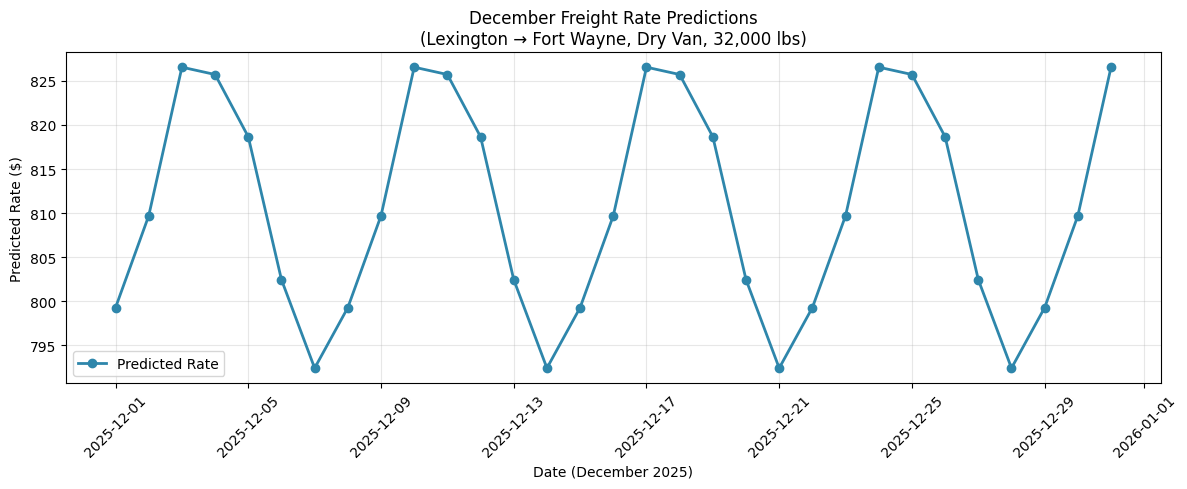


December stats:
  Mean: $810.80
  Min:  $792.43
  Max:  $826.55
  Std:  $12.28


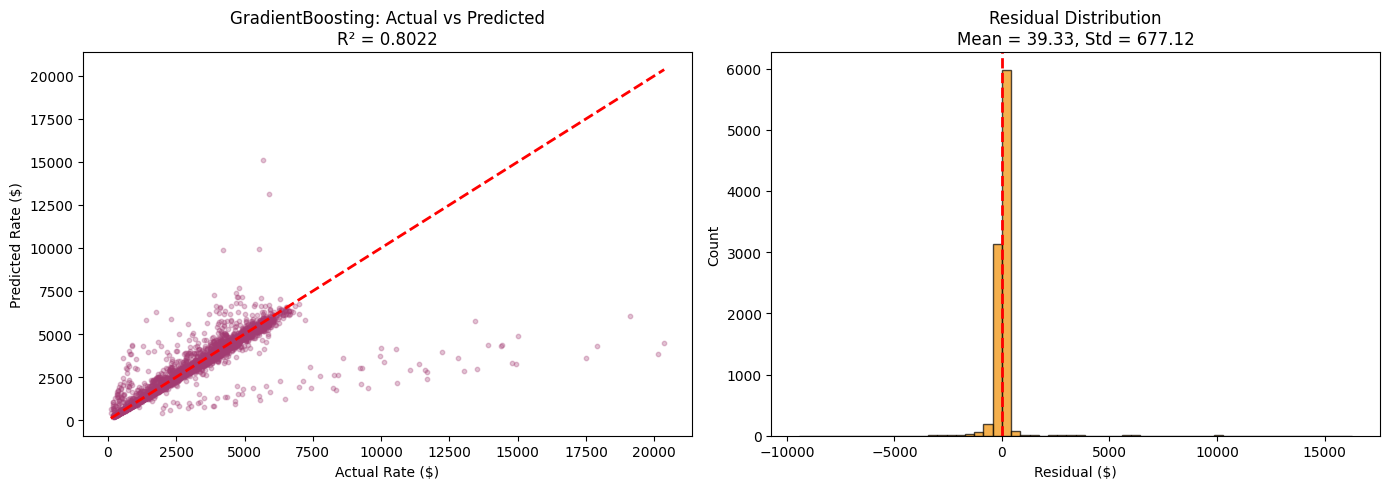

In [22]:
# ============================================================
# VALIDATION PREDICTIONS
# ============================================================

# Align validation features with training features
X_val_submit = val_fe[feature_cols]

# Predict
val_preds = best_model.predict(X_val_submit)

# Create submission CSV
submission = pd.DataFrame({
    'load_id': val_full['load_id'],
    'predicted_rate': val_preds
})
submission.to_csv('validation_predictions.csv', index=False)

print("✅ Saved: validation_predictions.csv")
print(submission.head(10))
print(f"\nValidation prediction stats:")
print(f"  Min:  ${val_preds.min():.2f}")
print(f"  Max:  ${val_preds.max():.2f}")
print(f"  Mean: ${val_preds.mean():.2f}")
print(f"  Std:  ${val_preds.std():.2f}")

# ============================================================
# DECEMBER CHART PREDICTIONS
# ============================================================

# Ensure December has all required feature columns
for col in feature_cols:
    if col not in dec_fe.columns:
        dec_fe[col] = -999  # same fill value used in training

X_dec = dec_fe[feature_cols]
dec_preds = best_model.predict(X_dec)

# Add predictions back to December dataframe
dec_full['predicted_rate'] = dec_preds

print(f"\n{'='*60}")
print("DECEMBER PREDICTIONS")
print(f"{'='*60}")
print(dec_full[['date', 'pickup', 'delivery', 'distance', 'weight', 'predicted_rate']].head(10))

# --- PLOT DECEMBER CHART ---
plt.figure(figsize=(12, 5))

dec_plot = dec_full.sort_values('date')
plt.plot(dec_plot['date'], dec_plot['predicted_rate'],
         marker='o', linewidth=2, markersize=6, color='#2E86AB', label='Predicted Rate')

plt.title('December Freight Rate Predictions\n(Lexington → Fort Wayne, Dry Van, 32,000 lbs)', fontsize=12)
plt.xlabel('Date (December 2025)')
plt.ylabel('Predicted Rate ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('december_prediction_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDecember stats:")
print(f"  Mean: ${dec_preds.mean():.2f}")
print(f"  Min:  ${dec_preds.min():.2f}")
print(f"  Max:  ${dec_preds.max():.2f}")
print(f"  Std:  ${dec_preds.std():.2f}")

# ============================================================
# VALIDATION ACTUAL VS PREDICTED (from time-based split)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_val, results[best_name]['preds'], alpha=0.3, s=10, color='#A23B72')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rate ($)')
axes[0].set_ylabel('Predicted Rate ($)')
axes[0].set_title(f'{best_name}: Actual vs Predicted\nR² = {results[best_name]["r2"]:.4f}')

# Residuals
residuals = y_val - results[best_name]['preds']
axes[1].hist(residuals, bins=60, edgecolor='black', color='#F18F01', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution\nMean = {residuals.mean():.2f}, Std = {residuals.std():.2f}')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================
# CREATE DECEMBER PREDICTIONS CSV FOR SCORE.PY
# ============================================================

# Start from the original December template (with original columns)
dec_submit = december.copy()

# Add our predictions
dec_submit['predicted_rate'] = dec_preds

# Ensure exactly the 7 columns score.py expects, in the right order
expected_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
dec_submit = dec_submit[expected_cols]

# Ensure data types match what score.py expects
dec_submit['distance'] = dec_submit['distance'].astype(float)
dec_submit['weight'] = dec_submit['weight'].astype(float)
dec_submit['date'] = pd.to_datetime(dec_submit['date']).dt.strftime('%Y-%m-%d')

# Save
dec_submit.to_csv('december_predictions.csv', index=False)

print("✅ Saved: december_predictions.csv")
print(dec_submit.head())
print(f"\nShape: {dec_submit.shape}")
print(f"Date range: {dec_submit['date'].min()} to {dec_submit['date'].max()}")
print(f"Predicted rate range: ${dec_submit['predicted_rate'].min():.2f} - ${dec_submit['predicted_rate'].max():.2f}")

# Double-check fixed values
print(f"\n--- Validation Checks ---")
print(f"Pickup all Lexington: {(dec_submit['pickup'] == 'Lexington').all()}")
print(f"Delivery all Fort Wayne: {(dec_submit['delivery'] == 'Fort Wayne').all()}")
print(f"Distance all 360.0: {np.isclose(dec_submit['distance'], 360.0).all()}")
print(f"Equipment all Dry Van: {(dec_submit['equipment'] == 'Dry Van').all()}")
print(f"Weight all 32000.0: {np.isclose(dec_submit['weight'], 32000.0).all()}")
print(f"All rates positive: {(dec_submit['predicted_rate'] > 0).all()}")
print(f"Exactly 31 rows: {len(dec_submit) == 31}")

✅ Saved: december_predictions.csv
      pickup    delivery  distance equipment   weight        date  \
0  Lexington  Fort Wayne     360.0   Dry Van  32000.0  2025-12-01   
1  Lexington  Fort Wayne     360.0   Dry Van  32000.0  2025-12-02   
2  Lexington  Fort Wayne     360.0   Dry Van  32000.0  2025-12-03   
3  Lexington  Fort Wayne     360.0   Dry Van  32000.0  2025-12-04   
4  Lexington  Fort Wayne     360.0   Dry Van  32000.0  2025-12-05   

   predicted_rate  
0      799.292711  
1      809.708684  
2      826.552008  
3      825.720122  
4      818.657817  

Shape: (31, 7)
Date range: 2025-12-01 to 2025-12-31
Predicted rate range: $792.43 - $826.55

--- Validation Checks ---
Pickup all Lexington: True
Delivery all Fort Wayne: True
Distance all 360.0: True
Equipment all Dry Van: True
Weight all 32000.0: True
All rates positive: True
Exactly 31 rows: True


In [27]:
# ============================================================
# REPLICATE SCORE.PY VALIDATION
# ============================================================

print("=" * 60)
print("VALIDATING PREDICTIONS")
print("=" * 60)

# Load your files
preds = pd.read_csv('validation_predictions.csv')
dec = pd.read_csv('december_predictions.csv')

# --- Check validation_predictions.csv ---
print("\n1. validation_predictions.csv")

# Columns
assert list(preds.columns) == ['load_id', 'predicted_rate'], "Wrong columns!"
print("   ✅ Columns correct")

# Row count
assert len(preds) == 12000, f"Wrong row count: {len(preds)}"
print("   ✅ 12,000 rows")

# No missing/duplicate IDs
assert preds['load_id'].notna().all(), "Missing IDs!"
assert not preds['load_id'].duplicated().any(), "Duplicate IDs!"
print("   ✅ No missing/duplicate IDs")

# Correct ID range
expected_ids = {f"TE-{i:06d}" for i in range(1, 12001)}
submitted_ids = set(preds['load_id'].astype(str))
assert expected_ids == submitted_ids, "ID mismatch!"
print("   ✅ All IDs match TE-000001 to TE-012000")

# Positive rates
rates = pd.to_numeric(preds['predicted_rate'], errors='coerce')
assert rates.notna().all(), "Invalid numeric values!"
assert np.isfinite(rates).all(), "Non-finite values!"
assert (rates > 0).all(), "Non-positive rates!"
print("   ✅ All rates positive and valid")

# --- Check december_predictions.csv ---
print("\n2. december_predictions.csv")

expected_dec_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
assert list(dec.columns) == expected_dec_cols, "Wrong columns!"
print("   ✅ Columns correct")

# Parse dates
dec['date'] = pd.to_datetime(dec['date'], errors='coerce')
assert dec['date'].notna().all(), "Invalid dates!"
print("   ✅ All dates valid")

# Numeric checks
dist = pd.to_numeric(dec['distance'], errors='coerce')
wt = pd.to_numeric(dec['weight'], errors='coerce')
pr = pd.to_numeric(dec['predicted_rate'], errors='coerce')
assert dist.notna().all() and np.isfinite(dist).all(), "Invalid distance!"
assert wt.notna().all() and np.isfinite(wt).all(), "Invalid weight!"
assert pr.notna().all() and np.isfinite(pr).all(), "Invalid predicted_rate!"
print("   ✅ All numeric values valid")

# 31 rows, Dec 1-31
expected_dates = pd.date_range("2025-12-01", "2025-12-31", freq="D")
assert len(dec) == 31, f"Wrong row count: {len(dec)}"
assert set(dec['date']) == set(expected_dates), "Date mismatch!"
print("   ✅ Exactly 31 days (Dec 1-31)")

# Fixed values
assert dec['pickup'].eq('Lexington').all(), "Pickup mismatch!"
assert dec['delivery'].eq('Fort Wayne').all(), "Delivery mismatch!"
assert np.isclose(dist, 360.0).all(), "Distance mismatch!"
assert dec['equipment'].eq('Dry Van').all(), "Equipment mismatch!"
assert np.isclose(wt, 32000.0).all(), "Weight mismatch!"
print("   ✅ All fixed values correct")

# Positive rates
assert (pr > 0).all(), "Non-positive December rates!"
print("   ✅ All December rates positive")

print("\n" + "=" * 60)
print("🎉 ALL VALIDATIONS PASSED!")
print("=" * 60)

VALIDATING PREDICTIONS

1. validation_predictions.csv
   ✅ Columns correct
   ✅ 12,000 rows
   ✅ No missing/duplicate IDs
   ✅ All IDs match TE-000001 to TE-012000
   ✅ All rates positive and valid

2. december_predictions.csv
   ✅ Columns correct
   ✅ All dates valid
   ✅ All numeric values valid
   ✅ Exactly 31 days (Dec 1-31)
   ✅ All fixed values correct
   ✅ All December rates positive

🎉 ALL VALIDATIONS PASSED!
